## Clean version of our assignment

Importing packages 

In [20]:
import pandas as pd
import os
import zipfile

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 

from sklearn import datasets as ds
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.decomposition import PCA
from sklearn import metrics
from sklearn import model_selection
from sklearn import preprocessing
from sklearn import decomposition

from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import SGDClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn import neighbors

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import OneHotEncoder, StandardScaler, RobustScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import sklearn.metrics as sklm
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.neural_network import MLPClassifier
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.tree import plot_tree
from sklearn.metrics import precision_score, recall_score, f1_score, roc_curve, auc, confusion_matrix, classification_report, average_precision_score, precision_recall_curve, PrecisionRecallDisplay
from scipy.stats import ttest_ind
from xgboost import XGBClassifier



Load data 

In [2]:
with zipfile.ZipFile("ecg_data.zip","r") as zip_ref:
    zip_ref.extractall("ecg_data")

def load_data():
    this_directory = os.getcwd()
    data = pd.read_csv(os.path.join(this_directory, 'ecg_data/ecg_data.csv'), index_col=0)
    return data

raw_data = load_data()

Data description

In [3]:
print(f'The number of samples: {len(raw_data.index)}')
print(f'The number of columns: {len(raw_data.columns)}')

print(f'The number of NaN values in the entire dataframe: {raw_data.isnull().sum().sum()}')
print(f'The number of samples with label 0: {len(raw_data[raw_data["label"] == 0])}')
print(f'The number of samples with label 1: {len(raw_data[raw_data["label"] == 1])}')
print(f'The percentage of samples with label 0 is thus {len(raw_data[raw_data["label"] == 0])/len(raw_data.index)*100:.2f}%', 
      f'and the percentage with label 1 {len(raw_data[raw_data["label"] == 1])/len(raw_data.index)*100:.2f}%')

# print(raw_data.groupby('label').count())
# print(raw_data.groupby('label').mean())
# print(raw_data.groupby('label').var())
# print(raw_data.groupby('label').std())


The number of samples: 827
The number of columns: 9001
The number of NaN values in the entire dataframe: 0
The number of samples with label 0: 681
The number of samples with label 1: 146
The percentage of samples with label 0 is thus 82.35% and the percentage with label 1 17.65%


Splitting the data in training and test sets

In [4]:
X = raw_data.drop('label', axis=1)
Y = raw_data['label']

x_train, x_test, y_train, y_test = train_test_split(X, Y, test_size=0.25, random_state=4, stratify=Y)

Preprocessing of data

In [7]:
### De gekozen volgorde van variantie -> lineaire correlatie -> t-test -> schalen heeft met name te maken met runtime verminderen
###         Daarnaast is schalen vóór de variantie-analyse sowieso niet handig, want dan schaalt de variantie schijnbaar mee
###             Dit komt door de gekozen schaalwijze
###         In deze volgorde zou nog geschoven kunnen worden als dat handig is.

print(f"Preprocessing begint met {np.shape(X)[1]} features")

### Filter de originele features o.b.v. variantie
###         Indien de variantie < 0.01 is, worden ze verwijderd.
###         Dit komt echter niet voor in onze dataset, dus dit verminderd het aantal features niet.
###             Dit zou kunnen komen door de outliers, ik weet niet zo goed of hier wat aan te doen is.
###     Eindresultaat --> 9000 features
redundant_features_variance = []
for col in X:
    if np.var(X[col]) < 0.01:
        redundant_features_variance.append(col)
X_variance_filtered = X.drop(columns=redundant_features_variance)

print(f"Variantie-analyse verwijderde {np.size(redundant_features_variance)} features")

### Filter de features o.b.v. lineaire correlatie
###         Indien de lineaire correlatie tussen twee features > 0.95 is, of < -0.95, dan wordt een van de twee verwijderd.
###         Hiermee kunnen 4574 features worden verwijderd.
###     Eindresultaat --> 4426 features
correlation_matrix = X_variance_filtered.corr().abs()
correlation_matrix_no_duplicates = correlation_matrix.where(np.triu(np.ones(correlation_matrix.shape), k=1).astype(bool))
redundant_features_correlation = []
for col in correlation_matrix:
    if any(correlation_matrix_no_duplicates[col] > 0.95):
        redundant_features_correlation.append(col)
X_correlation_filtered = X_variance_filtered.drop(columns=redundant_features_correlation)

print(f"Correlatie analyse verwijderde {np.size(redundant_features_correlation)} features")

### Filter de features o.b.v. t-test score
###         Indien de p-waarde van de t-test > 0.95, dan wordt deze verwijderd.
###             Hier gaat wel een Bonferonni correctie overheen, omdat anders bij toeval onzinnige features worden toegelaten.
###         De gedachte hierachter is dat deze features niet in staat om een verschil tussen de twee ECG-types aan te tonen.
###         T-test kan ook nog vervangen worden voor Mann-Whitney U test.
###             Bij een groot aantal samples zou T-test gebruikt mogen worden, ook als data niet normaal verdeeld is.
###             Maar wellicht iets om te vervangen als nodig.
###         Hiermee kunnen 4365 features worden verwijderd.
###     Eindresultaat --> 61 features
X_ttest_unfiltered_with_label = pd.concat([X_correlation_filtered, Y], axis=1)
redundant_features_ttest = []
for col in X_correlation_filtered:
    p_value = ttest_ind(X_ttest_unfiltered_with_label[X_ttest_unfiltered_with_label["label"] == 0][col], X_ttest_unfiltered_with_label[X_ttest_unfiltered_with_label["label"] == 1][col])[1]
    if p_value > (0.05/np.shape(X_correlation_filtered)[1]):
        redundant_features_ttest.append(col)
X_ttest_filtered = X_correlation_filtered.drop(columns=redundant_features_ttest)

print(f"T-test analyse verwijderde {np.size(redundant_features_ttest)} features")

### Schaal de data om orde-grootte verschillen te beperken.
###         Hier gekozen voor Robuust, omdat de data (vgm) niet normaal verdeeld is en outliers bevat.
###         Omgang met missende data hier niet nodig, onze dataset bevat geen NaN.
###         Doordat we niet weten wat de features in onze dataset betekenen, kunnen we onrealistische waarden ook niet verwijderen.
scaler = RobustScaler()
preprocessed_data = pd.DataFrame(scaler.fit_transform(X_ttest_filtered), columns=X_ttest_filtered.columns)

print(f"Na het schalen zijn er {np.shape(preprocessed_data)[1]} features over")

Preprocessing begint met 9000 features
Variantie-analyse verwijderde 0 features
Correlatie analyse verwijderde 4574 features
T-test analyse verwijderde 4365 features
Na het schalen zijn er 61 features over


In [12]:
# Bereken de scale_pos_weight om de extreme imbalans tegen te gaan
neg_class = len(y_train[y_train == 0])
pos_class = len(y_train[y_train == 1])
scale_pos_weight_val = neg_class / pos_class
print(f"Berekende scale_pos_weight: {scale_pos_weight_val:.2f}\n")


Berekende scale_pos_weight: 4.69



Start PCA + XGBoost RandomizedSearch (40 iteraties)...
Fitting 3 folds for each of 40 candidates, totalling 120 fits
[CV] END pca__n_components=100, xgb__colsample_bytree=0.5, xgb__learning_rate=0.2, xgb__max_depth=3, xgb__n_estimators=300, xgb__reg_alpha=5, xgb__reg_lambda=1, xgb__subsample=1.0; total time=   4.3s
[CV] END pca__n_components=100, xgb__colsample_bytree=0.5, xgb__learning_rate=0.2, xgb__max_depth=3, xgb__n_estimators=300, xgb__reg_alpha=5, xgb__reg_lambda=1, xgb__subsample=1.0; total time=   4.3s
[CV] END pca__n_components=100, xgb__colsample_bytree=0.5, xgb__learning_rate=0.2, xgb__max_depth=3, xgb__n_estimators=300, xgb__reg_alpha=5, xgb__reg_lambda=1, xgb__subsample=1.0; total time=   4.3s
[CV] END pca__n_components=50, xgb__colsample_bytree=0.5, xgb__learning_rate=0.01, xgb__max_depth=5, xgb__n_estimators=200, xgb__reg_alpha=0.1, xgb__reg_lambda=50, xgb__subsample=0.5; total time=   4.4s
[CV] END pca__n_components=50, xgb__colsample_bytree=0.5, xgb__learning_rate=0.0

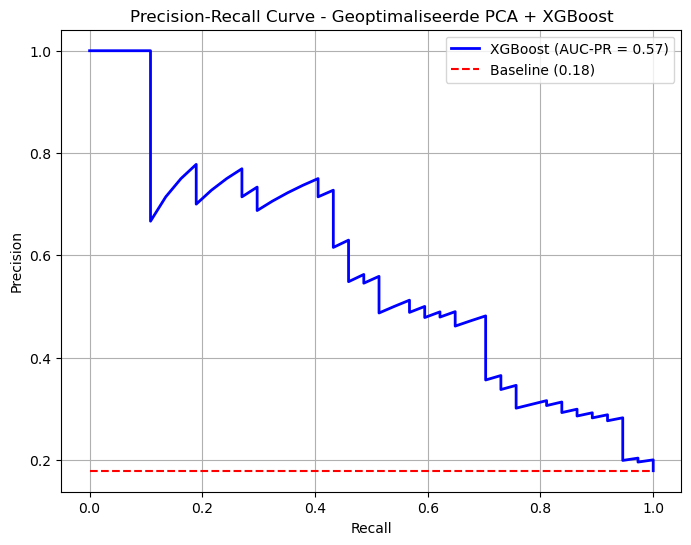

In [ ]:
from sklearn.model_selection import RandomizedSearchCV

# 1. Scale pos weight
scale_pos_weight_val = len(y_train[y_train == 0]) / len(y_train[y_train == 1])

# 2. Pipeline opzetten
pipeline = Pipeline([
    ('pca', PCA(random_state=42)),
    ('xgb', XGBClassifier(
        objective='binary:logistic',
        scale_pos_weight=scale_pos_weight_val,
        random_state=42,
        eval_metric='logloss',
        tree_method='hist'
    ))
])

# 3. UITGEBREIDE parameter grid
param_distributions = {
    # PCA instellingen: Hoeveel features houden we over? (Vaak is meer niet altijd beter)
    'pca__n_components': [50, 100, 150, 200], 
    
    # XGBoost Bomen parameters
    'xgb__learning_rate': [0.01, 0.05, 0.1, 0.2], 
    'xgb__max_depth': [2, 3, 4, 5],             
    'xgb__n_estimators': [100, 200, 300, 500],  
    
    # Subsampling (tegen overfitting op de testset)
    'xgb__subsample': [0.5, 0.7, 0.9, 1.0],     
    'xgb__colsample_bytree': [0.5, 0.7, 0.9],   
    
    # Regularisatie (L1 en L2 penalty)
    'xgb__reg_alpha': [0, 0.1, 1, 5],       # L1 (Lasso)
    'xgb__reg_lambda': [1, 5, 10, 50]       # L2 (Ridge)
}

# 4. Kruisvalidatie (Houd op n_splits=3 voor de snelheid)
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

# 5. RandomizedSearchCV met 30 tot 40 iteraties voor een goede mix
random_search = RandomizedSearchCV(
    estimator=pipeline,
    param_distributions=param_distributions,
    n_iter=40,          # We proberen nu 40 random combinaties!
    scoring='average_precision', 
    cv=cv,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

print("Start PCA + XGBoost RandomizedSearch (40 iteraties)...")
random_search.fit(x_train, y_train)

print(f"\n--- Resultaten ---")
print(f"Beste parameters: {random_search.best_params_}")
print(f"Beste gemiddelde Validatie AUC-PR: {random_search.best_score_:.4f}")

# 6. Evalueren op de Test Set
best_model = random_search.best_estimator_
y_pred = best_model.predict(x_test)
y_pred_proba = best_model.predict_proba(x_test)[:, 1]

test_auc_pr = average_precision_score(y_test, y_pred_proba)

accuracy = accuracy_score(y_test, y_pred)
precision_val = precision_score(y_test, y_pred)
recall_val = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"\n--- Evaluatie op Test Set ---")
print(f"Test AUC-PR: {test_auc_pr:.4f}")
print(f"Accuracy:  {accuracy:.4f}  (Let op: door de imbalans is dit getal vaak geflatteerd)")
print(f"Precision: {precision_val:.4f}  (Hoeveel van de voorspelde '1'en waren écht '1')")
print(f"Recall:    {recall_val:.4f}  (Hoeveel van de échte '1'en hebben we gevonden?)")
print(f"F1-Score:  {f1:.4f}  (Harmonisch gemiddelde tussen Precision en Recall)")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

# 7. Plot de curve
precision, recall, _ = precision_recall_curve(y_test, y_pred_proba)
baseline = len(y_test[y_test == 1]) / len(y_test)

plt.figure(figsize=(8, 6))
plt.plot(recall, precision, color='blue', lw=2, label=f'XGBoost (AUC-PR = {test_auc_pr:.2f})')
plt.plot([0, 1], [baseline, baseline], linestyle='--', color='red', label=f'Baseline ({baseline:.2f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve - Geoptimaliseerde PCA + XGBoost')
plt.legend(loc="upper right")
plt.grid(True)
plt.show()


Training XGBoost op jouw 61 handmatig geselecteerde features...

--- Model Evaluatie op Test Set ---
AUC-PR:    0.5871
Accuracy:  0.8309
Precision: 0.5278
Recall:    0.5135
F1-Score:  0.5205

--- Confusion Matrix ---
True Negatives (0 goed): 153
False Positives (0 fout): 17
False Negatives (1 fout): 18
True Positives (1 goed): 19


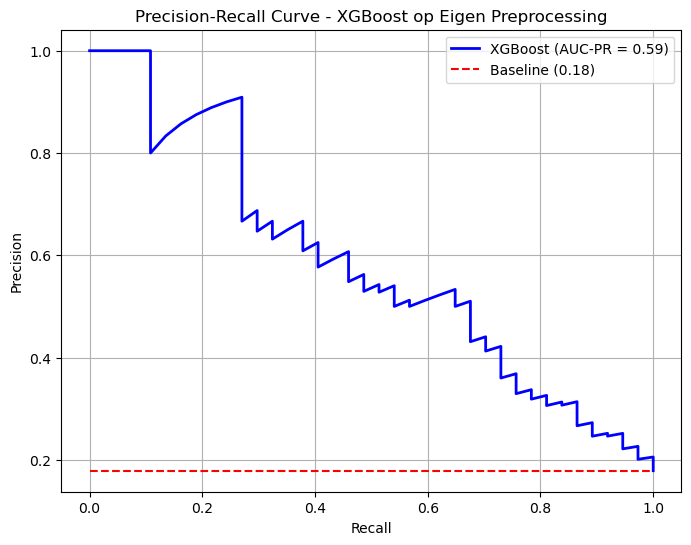

In [ ]:
from sklearn.metrics import accuracy_score

# Gebruik JOUW preprocessed_data en de Y van eerder
x_train_prep, x_test_prep, y_train_prep, y_test_prep = train_test_split(
    preprocessed_data, Y, test_size=0.25, random_state=4, stratify=Y
)

# 1. Scale pos weight (compensatie voor 82% label 0 vs 18% label 1)
scale_pos_weight_val = len(y_train_prep[y_train_prep == 0]) / len(y_train_prep[y_train_prep == 1])

# 2. De XGBoost Classifier met GEOPTIMALISEERDE parameters voor JOUW 61 features
print(f"Training XGBoost op jouw {x_train_prep.shape[1]} handmatig geselecteerde features...")
xgb_model_prep = XGBClassifier(
    objective='binary:logistic',
    scale_pos_weight=scale_pos_weight_val,
    
    # --- Nieuwe beste parameters voor deze specifieke data ---
    learning_rate=0.01,         # Veel langzamer leren...
    n_estimators=300,           # ...met iets meer bomen
    max_depth=4,                # Bomen mogen íetsje dieper (4 ipv 3)
    min_child_weight=5,         # Maar bladeren moeten veel extra bewijs hebben (5)
    
    subsample=0.7,              # 70% van de patiënten per boom
    colsample_bytree=0.6,       # 60% van je 61 features per boom (~36 features per boom)
    
    reg_alpha=0.5,              # L1 Regularisatie iets omhoog (zet nutteloze overgebleven features op 0)
    reg_lambda=1,               # L2 Regularisatie
    # -------------------------------------------------------------
    
    random_state=42,
    eval_metric='logloss',
    tree_method='hist',
    n_jobs=-1
)

# 3. Fit direct op de data 
xgb_model_prep.fit(x_train_prep, y_train_prep)

# 4. Voorspellingen maken op de Test Set
y_pred = xgb_model_prep.predict(x_test_prep)
y_pred_proba = xgb_model_prep.predict_proba(x_test_prep)[:, 1]

# 5. Alle metrieken berekenen
test_auc_pr = average_precision_score(y_test_prep, y_pred_proba)
accuracy = accuracy_score(y_test_prep, y_pred)
precision_val = precision_score(y_test_prep, y_pred)
recall_val = recall_score(y_test_prep, y_pred)
f1 = f1_score(y_test_prep, y_pred)

print(f"\n--- Model Evaluatie op Test Set ---")
print(f"AUC-PR:    {test_auc_pr:.4f}")
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision_val:.4f}")
print(f"Recall:    {recall_val:.4f}")
print(f"F1-Score:  {f1:.4f}")

print("\n--- Confusion Matrix ---")
cm = confusion_matrix(y_test_prep, y_pred)
print("True Negatives (0 goed):", cm[0,0])
print("False Positives (0 fout):", cm[0,1])
print("False Negatives (1 fout):", cm[1,0]) 
print("True Positives (1 goed):", cm[1,1])

# 6. Plot de curve
precision, recall, _ = precision_recall_curve(y_test_prep, y_pred_proba)
baseline = len(y_test_prep[y_test_prep == 1]) / len(y_test_prep)

plt.figure(figsize=(8, 6))
plt.plot(recall, precision, color='blue', lw=2, label=f'XGBoost (AUC-PR = {test_auc_pr:.2f})')
plt.plot([0, 1], [baseline, baseline], linestyle='--', color='red', label=f'Baseline ({baseline:.2f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve - XGBoost op Eigen Preprocessing')
plt.legend(loc="upper right")
plt.grid(True)
plt.show()
